In [1]:
from pathlib import Path

OUTPUT_DIR = Path(
    r"C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(OUTPUT_DIR)

C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks


In [2]:
print(OUTPUT_DIR.exists())

True


In [3]:
import requests
import pandas as pd
import pathlib
import threading
import concurrent.futures
import time
from io import StringIO

BASE_URL = 'https://www.datos.gov.co/resource/p6dx-8zbt.csv'

# Carpeta de destino exacta
OUTPUT_DIR = pathlib.Path(
    r'C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks'
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Carpeta de salida:', OUTPUT_DIR)
print('Existe:', OUTPUT_DIR.exists())

def descargar_lote(offset, limit=1000):
    # Descarga 'limit' filas desde 'offset' y guarda un CSV
    url = f'{BASE_URL}?$limit={limit}&$offset={offset}'

    # Identificar qué hilo está ejecutando esta función
    hilo_nombre = threading.current_thread().name
    hilo_num = hilo_nombre.split('_')[-1] if '_' in hilo_nombre else '0'

    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    df = pd.read_csv(StringIO(resp.text))

    # Guardar como CSV individual
    ruta = OUTPUT_DIR / f'prueba_chunk_{offset:07d}.csv'
    df.to_csv(ruta, index=False)

    print(f'  [Hilo-{hilo_num}] offset={offset:,}: {len(df)} filas  →  {ruta}')
    return df

offsets_prueba = [0, 1000, 2000]

# --- SECUENCIAL ---
print('=== SECUENCIAL (1 hilo) ===')
t0 = time.time()
dfs_seq = [descargar_lote(o) for o in offsets_prueba]
t_seq = time.time() - t0
print(f'Tiempo: {t_seq:.1f}s\n')

# --- PARALELO ---
print('=== PARALELO (3 hilos) ===')
t0 = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=3) as executor:
    dfs_par = list(executor.map(descargar_lote, offsets_prueba))
t_par = time.time() - t0
print(f'Tiempo: {t_par:.1f}s')
print(f'Speedup: {t_seq / t_par:.2f}x')

# Verificar CSVs guardados
print()
print('Archivos CSV guardados:')
for f in sorted(OUTPUT_DIR.glob('prueba_chunk_*.csv')):
    print(f'  {f}  ({f.stat().st_size/1024:.0f} KB)')

Carpeta de salida: C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks
Existe: True
=== SECUENCIAL (1 hilo) ===
  [Hilo-0] offset=0: 1000 filas  →  C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks\prueba_chunk_0000000.csv
  [Hilo-0] offset=1,000: 1000 filas  →  C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks\prueba_chunk_0001000.csv
  [Hilo-0] offset=2,000: 1000 filas  →  C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks\prueba_chunk_0002000.csv
Tiempo: 3.0s

=== PARALELO (3 hilos) ===
  [Hilo-2] offset=2,000: 1000 filas  →  C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks\prueba_chunk_0002000.csv
  [Hilo-1] offset=1,000: 1000 filas  →  C:\Users\ser_s\Des

Benchmark: descarga de 6 lotes x 1,000 filas con diferente numero de hilos
Observa el ORDEN en que aparecen los mensajes [Hilo-X]

--- 1 hilo(s) ---
  [Hilo-0] offset=0: 1000 filas  →  C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks\prueba_chunk_0000000.csv
  [Hilo-0] offset=1,000: 1000 filas  →  C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks\prueba_chunk_0001000.csv
  [Hilo-0] offset=2,000: 1000 filas  →  C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks\prueba_chunk_0002000.csv
  [Hilo-0] offset=3,000: 1000 filas  →  C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks\prueba_chunk_0003000.csv
  [Hilo-0] offset=4,000: 1000 filas  →  C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cu

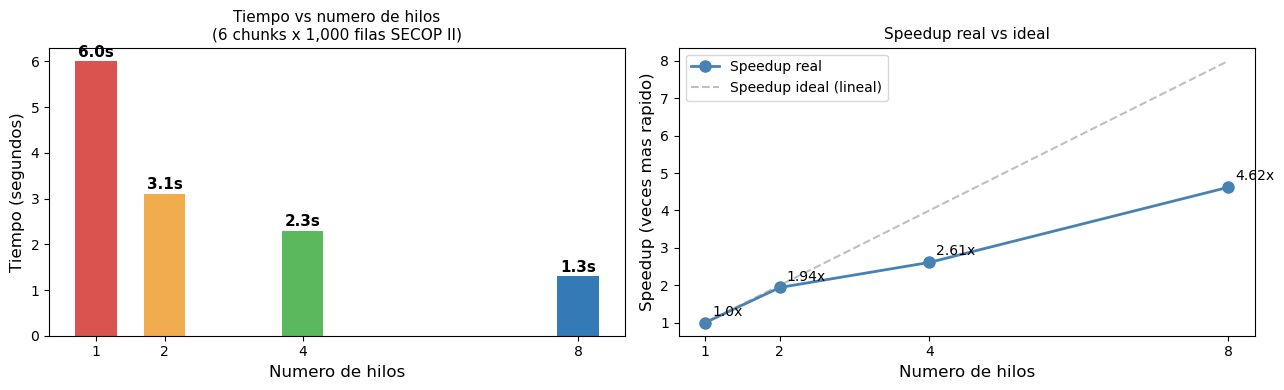

Speedup maximo obtenido: 4.62x con 8 hilos


In [4]:
import matplotlib.pyplot as plt
import concurrent.futures, time

# offsets para el benchmark: 6 lotes de 1,000 filas cada uno
offsets_bench = [0, 1000, 2000, 3000, 4000, 5000]
tiempos = {}

print('Benchmark: descarga de 6 lotes x 1,000 filas con diferente numero de hilos')
print('Observa el ORDEN en que aparecen los mensajes [Hilo-X]\n')

for nw in [1, 2, 4, 8]:
    print(f'--- {nw} hilo(s) ---')
    t0 = time.time()
    with concurrent.futures.ThreadPoolExecutor(max_workers=nw) as executor:
        list(executor.map(descargar_lote, offsets_bench))
    tiempos[nw] = round(time.time() - t0, 1)
    print(f'>>> {nw} hilo(s): {tiempos[nw]:.1f}s\n')

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfica 1: Tiempo
colores = ['#d9534f', '#f0ad4e', '#5cb85c', '#337ab7']
bars = axes[0].bar(list(tiempos.keys()), list(tiempos.values()), color=colores, width=0.6)
for bar, val in zip(bars, tiempos.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val}s', ha='center', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Numero de hilos', fontsize=12)
axes[0].set_ylabel('Tiempo (segundos)', fontsize=12)
axes[0].set_title('Tiempo vs numero de hilos\n(6 chunks x 1,000 filas SECOP II)', fontsize=11)
axes[0].set_xticks([1, 2, 4, 8])

# Gráfica 2: Speedup
t1 = tiempos[1]
speedups = {nw: round(t1/t, 2) for nw, t in tiempos.items()}
axes[1].plot(list(speedups.keys()), list(speedups.values()), 'o-', color='steelblue',
             linewidth=2, markersize=8, label='Speedup real')
axes[1].plot([1, 8], [1, 8], '--', color='gray', alpha=0.5, label='Speedup ideal (lineal)')
for nw, sp in speedups.items():
    axes[1].annotate(f'{sp}x', (nw, sp), textcoords='offset points', xytext=(5, 5), fontsize=10)
axes[1].set_xlabel('Numero de hilos', fontsize=12)
axes[1].set_ylabel('Speedup (veces mas rapido)', fontsize=12)
axes[1].set_title('Speedup real vs ideal', fontsize=11)
axes[1].legend()
axes[1].set_xticks([1, 2, 4, 8])

plt.tight_layout()
plt.show()
print(f'Speedup maximo obtenido: {max(speedups.values())}x con {max(speedups, key=speedups.get)} hilos')

In [5]:
# Descargar una muestra pequeña para ver el schema real
sample_url = f'{BASE_URL}?$limit=3'
sample = pd.read_csv(StringIO(requests.get(sample_url, timeout=30).text))

print(f'Total de columnas disponibles: {len(sample.columns)}')
print('-' * 65)
for col in sorted(sample.columns):
    ejemplo = sample[col].dropna()
    ej_str = str(ejemplo.iloc[0])[:45] if len(ejemplo) > 0 else 'N/A'
    print(f'  {col:<45} -> {ej_str}')

Total de columnas disponibles: 59
-----------------------------------------------------------------
  adjudicado                                    -> No
  categorias_adicionales                        -> No definido
  ciudad_de_la_unidad_de                        -> Bogotá
  ciudad_entidad                                -> Bogotá
  ciudad_proveedor                              -> No Definido
  codigo_entidad                                -> 700474109
  codigo_pci                                    -> Centralizada
  codigo_principal_de_categoria                 -> V1.80111500
  codigoproveedor                               -> No Definido
  conteo_de_respuestas_a_ofertas                -> 0
  departamento_entidad                          -> Distrito Capital de Bogotá
  departamento_proveedor                        -> No Definido
  descripci_n_del_procedimiento                 -> TS_MERCADO_2022_GEIH_TH Prestación de servici
  duracion                                      -> 344
  entid

In [6]:
# Descargar TODO el dataset en lotes paralelos de 100,000
# Cada lote se guarda como un CSV independiente en datos/secop_chunks/
# → Dask leerá cada CSV como una PARTICIÓN separada

CHUNK = 100_000
TOTAL_FILAS = 8_410_000
offsets_totales = list(range(0, TOTAL_FILAS, CHUNK))

def descargar_chunk(offset):
    # Descarga CHUNK filas desde 'offset' y guarda CSV
    url = f'{BASE_URL}?$limit={CHUNK}&$offset={offset}'
    hilo_nombre = threading.current_thread().name
    hilo_num = hilo_nombre.split('_')[-1] if '_' in hilo_nombre else '0'

    print(f'  [Hilo-{hilo_num}] Iniciando offset={offset:,}...')
    resp = requests.get(url, timeout=300)
    resp.raise_for_status()
    df = pd.read_csv(StringIO(resp.text), low_memory=False)

    # Guardar CSV individual
    ruta = pathlib.Path(f'datos/secop_chunks/secop_chunk_{offset:07d}.csv')
    df.to_csv(ruta, index=False)

    mem_mb = df.memory_usage(deep=True).sum() / 1e6
    tam_kb = ruta.stat().st_size / 1024
    print(f'  [Hilo-{hilo_num}] OK offset={offset:,}: {len(df):,} filas | '
          f'{mem_mb:.1f} MB RAM | {tam_kb:.0f} KB en disco -> {ruta.name}')
    
    return {
        'offset': offset,
        'filas': len(df),
        'columnas': df.shape[1],
        'mem_mb': mem_mb,
        'ruta': ruta
    }

print(f'Descargando {TOTAL_FILAS:,} filas del SECOP II en lotes de {CHUNK:,}...')
print('Cada lote se guarda como CSV separado en datos/secop_chunks/')
print(f'Total de offsets a descargar: {len(offsets_totales)}')
print()

t0 = time.time()
with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
    resultados = list(executor.map(descargar_chunk, offsets_totales))

t_total = time.time() - t0

total_filas = sum(r['filas'] for r in resultados)
num_columnas = resultados[0]['columnas'] if resultados else 0

print()
print('=' * 60)
print(f'Total descargado:  {total_filas:,} filas x {num_columnas} columnas')
print(f'Tiempo total:      {t_total:.1f}s')

# Mostrar estructura de la carpeta
print()
print('Estructura de la carpeta datos/secop_chunks/:')
csvs = sorted(pathlib.Path('datos/secop_chunks').glob('secop_chunk_*.csv'))
for csv in csvs:
    print(f'  {csv.name}  ({csv.stat().st_size/1024:.0f} KB)')
print(f'\n  -> Dask leerá estos {len(csvs)} archivos como {len(csvs)} particiones')

Descargando 8,410,000 filas del SECOP II en lotes de 100,000...
Cada lote se guarda como CSV separado en datos/secop_chunks/
Total de offsets a descargar: 85

  [Hilo-0] Iniciando offset=0...
  [Hilo-1] Iniciando offset=100,000...
  [Hilo-0] OK offset=0: 100,000 filas | 142.5 MB RAM | 101924 KB en disco -> secop_chunk_0000000.csv
  [Hilo-0] Iniciando offset=200,000...
  [Hilo-0] OK offset=200,000: 100,000 filas | 141.5 MB RAM | 101832 KB en disco -> secop_chunk_0200000.csv
  [Hilo-0] Iniciando offset=300,000...
  [Hilo-1] OK offset=100,000: 100,000 filas | 141.6 MB RAM | 101987 KB en disco -> secop_chunk_0100000.csv
  [Hilo-1] Iniciando offset=400,000...
  [Hilo-0] OK offset=300,000: 100,000 filas | 141.5 MB RAM | 101843 KB en disco -> secop_chunk_0300000.csv
  [Hilo-0] Iniciando offset=500,000...
  [Hilo-1] OK offset=400,000: 100,000 filas | 141.4 MB RAM | 101745 KB en disco -> secop_chunk_0400000.csv
  [Hilo-1] Iniciando offset=600,000...
  [Hilo-1] OK offset=600,000: 100,000 filas |

In [9]:
import dask.dataframe as dd
from pathlib import Path

DATA_DIR = Path(
    r"C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks"
)

files = sorted(DATA_DIR.glob("secop_chunk_*.csv"))

print("CSV files found:", len(files))
print("First file:", files[0] if files else "No files found")

ddf = dd.read_csv(
    str(DATA_DIR / "secop_chunk_*.csv"),
    dtype="object",
    assume_missing=True,
    blocksize=None
)

print("Dask partitions:", ddf.npartitions)
print("Columns:")
print(ddf.columns.tolist())

CSV files found: 85
First file: C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks\secop_chunk_0000000.csv
Dask partitions: 85
Columns:
['entidad', 'nit_entidad', 'departamento_entidad', 'ciudad_entidad', 'ordenentidad', 'codigo_pci', 'id_del_proceso', 'referencia_del_proceso', 'ppi', 'id_del_portafolio', 'nombre_del_procedimiento', 'descripci_n_del_procedimiento', 'fase', 'fecha_de_publicacion_del', 'fecha_de_ultima_publicaci', 'fecha_de_publicacion_fase', 'fecha_de_publicacion_fase_1', 'fecha_de_publicacion', 'fecha_de_publicacion_fase_2', 'fecha_de_publicacion_fase_3', 'precio_base', 'modalidad_de_contratacion', 'justificaci_n_modalidad_de', 'duracion', 'unidad_de_duracion', 'fecha_de_recepcion_de', 'fecha_de_apertura_de_respuesta', 'fecha_de_apertura_efectiva', 'ciudad_de_la_unidad_de', 'nombre_de_la_unidad_de', 'proveedores_invitados', 'proveedores_con_invitacion', 'visualizaciones_del', 'proveedores_que_manifestaro

In [10]:
print(ddf.columns.tolist())

['entidad', 'nit_entidad', 'departamento_entidad', 'ciudad_entidad', 'ordenentidad', 'codigo_pci', 'id_del_proceso', 'referencia_del_proceso', 'ppi', 'id_del_portafolio', 'nombre_del_procedimiento', 'descripci_n_del_procedimiento', 'fase', 'fecha_de_publicacion_del', 'fecha_de_ultima_publicaci', 'fecha_de_publicacion_fase', 'fecha_de_publicacion_fase_1', 'fecha_de_publicacion', 'fecha_de_publicacion_fase_2', 'fecha_de_publicacion_fase_3', 'precio_base', 'modalidad_de_contratacion', 'justificaci_n_modalidad_de', 'duracion', 'unidad_de_duracion', 'fecha_de_recepcion_de', 'fecha_de_apertura_de_respuesta', 'fecha_de_apertura_efectiva', 'ciudad_de_la_unidad_de', 'nombre_de_la_unidad_de', 'proveedores_invitados', 'proveedores_con_invitacion', 'visualizaciones_del', 'proveedores_que_manifestaron', 'respuestas_al_procedimiento', 'respuestas_externas', 'conteo_de_respuestas_a_ofertas', 'proveedores_unicos_con', 'numero_de_lotes', 'estado_del_procedimiento', 'id_estado_del_procedimiento', 'adjud

In [11]:
sample = ddf[[
    "departamento_entidad",
    "valor_total_adjudicacion",
    "fecha_de_publicacion_del"
]].head(50)

print(sample)

          departamento_entidad valor_total_adjudicacion  \
0   Distrito Capital de Bogotá                        0   
1   Distrito Capital de Bogotá                        0   
2   Distrito Capital de Bogotá                    40000   
3                    Antioquia                        0   
4   Distrito Capital de Bogotá                        0   
5                       Caldas                        0   
6   Distrito Capital de Bogotá                        0   
7                     Putumayo                        0   
8                 Cundinamarca                        0   
9                    Antioquia                        0   
10  Distrito Capital de Bogotá                 37842000   
11  Distrito Capital de Bogotá                        0   
12  Distrito Capital de Bogotá                        0   
13                      Nariño                        0   
14                   Antioquia                        0   
15                   Santander                305644297 

In [12]:
ddf["adjudicado"].value_counts().compute()

adjudicado
No    7617959
Si     793810
Name: count, dtype: int64

In [13]:
(ddf["valor_total_adjudicacion"]==0).sum().compute()

np.int64(0)

In [15]:
dept_counts = (
    ddf["departamento_entidad"]
    .value_counts()
    .compute()
    .sort_values(ascending=False)
)

print(dept_counts.head(40))

departamento_entidad
Distrito Capital de Bogotá                  2437365
Antioquia                                    888993
Valle del Cauca                              626641
No Definido                                  559254
Cundinamarca                                 398579
Santander                                    344475
Boyacá                                       230418
Bolívar                                      225189
Magdalena                                    223173
Nariño                                       215528
Atlántico                                    196304
Tolima                                       195855
Norte de Santander                           190007
Meta                                         168307
Caldas                                       164567
Huila                                        163065
Risaralda                                    158262
Quindío                                      141841
Cauca                                      

### NORMALIZACIÓN DE NOMBRES DE COLUMNAS


In [16]:
ddf.columns = (
    ddf.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("\nColumnas normalizadas correctamente.")


Columnas normalizadas correctamente.


In [ ]:
# ============================================================
# PIPELINE COMPLETO SECOP II - DASK + DESCARGA + LIMPIEZA Q1
# ============================================================

import requests
import pandas as pd
import dask.dataframe as dd
import pathlib
import threading
import concurrent.futures
import time
from io import StringIO

# ============================================================
# 1. CONFIGURACIÓN GENERAL
# ============================================================

BASE_URL = "https://www.datos.gov.co/resource/p6dx-8zbt.csv"

DATA_DIR = pathlib.Path(
    r"C:\Users\ser_s\Desktop\Maestria Analitica\Big Data\Big_Data\Big_Data_Grupo_6\Taller2\Cuadernillos\datos\secop_chunks"
)

DATA_DIR.mkdir(parents=True, exist_ok=True)

CHUNK = 100_000
TOTAL_FILAS = 8_410_000
MAX_WORKERS = 2
MAX_REINTENTOS = 3

offsets_totales = list(range(0, TOTAL_FILAS, CHUNK))

print("Carpeta de salida:", DATA_DIR)
print("Total de offsets:", len(offsets_totales))


# ============================================================
# 2. FUNCIÓN DE DESCARGA POR CHUNK
# ============================================================

def descargar_chunk(offset):
    ruta = DATA_DIR / f"secop_chunk_{offset:07d}.csv"

    # Evitar descargar de nuevo si el archivo ya existe
    if ruta.exists() and ruta.stat().st_size > 0:
        print(f"  [SKIP] Ya existe: {ruta.name}")
        return {
            "offset": offset,
            "filas": None,
            "columnas": None,
            "estado": "existente",
            "ruta": ruta
        }

    url = f"{BASE_URL}?$limit={CHUNK}&$offset={offset}"
    hilo_nombre = threading.current_thread().name
    hilo_num = hilo_nombre.split("_")[-1] if "_" in hilo_nombre else "0"

    for intento in range(1, MAX_REINTENTOS + 1):
        try:
            print(f"  [Hilo-{hilo_num}] Descargando offset={offset:,} | intento {intento}")

            resp = requests.get(url, timeout=300)
            resp.raise_for_status()

            df = pd.read_csv(StringIO(resp.text), low_memory=False)

            if df.empty:
                print(f"  [Hilo-{hilo_num}] Offset={offset:,} sin datos.")
                return {
                    "offset": offset,
                    "filas": 0,
                    "columnas": 0,
                    "estado": "vacio",
                    "ruta": ruta
                }

            df.to_csv(ruta, index=False)

            mem_mb = df.memory_usage(deep=True).sum() / 1e6
            tam_mb = ruta.stat().st_size / (1024 * 1024)

            print(
                f"  [Hilo-{hilo_num}] OK offset={offset:,}: "
                f"{len(df):,} filas | {mem_mb:.1f} MB RAM | "
                f"{tam_mb:.1f} MB disco -> {ruta.name}"
            )

            return {
                "offset": offset,
                "filas": len(df),
                "columnas": df.shape[1],
                "mem_mb": mem_mb,
                "estado": "descargado",
                "ruta": ruta
            }

        except Exception as e:
            print(f"  [Hilo-{hilo_num}] ERROR offset={offset:,}, intento {intento}: {e}")
            time.sleep(5)

    return {
        "offset": offset,
        "filas": 0,
        "columnas": 0,
        "estado": "error",
        "ruta": ruta
    }


# ============================================================
# 3. DESCARGA PARALELA
# ============================================================

print("\nIniciando descarga paralela...")
t0 = time.time()

with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    resultados = list(executor.map(descargar_chunk, offsets_totales))

t_total = time.time() - t0

resumen_descarga = pd.DataFrame(resultados)

print("\n" + "=" * 70)
print("RESUMEN DE DESCARGA")
print("=" * 70)
print(resumen_descarga["estado"].value_counts())
print(f"Tiempo total descarga: {t_total:.1f} segundos")

csvs = sorted(DATA_DIR.glob("secop_chunk_*.csv"))

print(f"\nArchivos CSV disponibles: {len(csvs)}")
print(f"Dask leerá estos {len(csvs)} archivos como particiones.")


# ============================================================
# 4. CARGA CON DASK DATAFRAME
# ============================================================

print("\nCargando archivos con Dask...")

ddf = dd.read_csv(
    str(DATA_DIR / "secop_chunk_*.csv"),
    dtype="object",
    assume_missing=True,
    blocksize=None
)

print("Particiones Dask:", ddf.npartitions)
print("Columnas cargadas:", len(ddf.columns))


# ============================================================
# 5. NORMALIZACIÓN DE NOMBRES DE COLUMNAS
# ============================================================

ddf.columns = (
    ddf.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("\nColumnas normalizadas correctamente.")


# ============================================================
# 6. SELECCIÓN DE VARIABLES PREGUNTA 1
# ============================================================

cols_q1 = [
    "departamento_entidad",
    "valor_total_adjudicacion",
    "fecha_de_publicacion_del",
    "adjudicado"
]

faltantes = [c for c in cols_q1 if c not in ddf.columns]

if faltantes:
    raise ValueError(f"Faltan columnas requeridas para Pregunta 1: {faltantes}")

ddf_q1_raw = ddf[cols_q1].copy()

print("\nDataFrame auxiliar creado: ddf_q1_raw")
print(ddf_q1_raw.dtypes)


# ============================================================
# 7. DIAGNÓSTICO INICIAL
# ============================================================

print("\n" + "=" * 70)
print("DIAGNÓSTICO INICIAL PREGUNTA 1")
print("=" * 70)

total_registros = ddf_q1_raw.shape[0].compute()
nulos_iniciales = ddf_q1_raw.isna().sum().compute()

print("Total registros:", f"{total_registros:,}")
print("\nNulos iniciales:")
print(nulos_iniciales)

print("\nDistribución de adjudicado:")
print(
    ddf_q1_raw["adjudicado"]
    .value_counts()
    .compute()
    .sort_values(ascending=False)
)

print("\nTop departamentos iniciales:")
print(
    ddf_q1_raw["departamento_entidad"]
    .value_counts()
    .compute()
    .sort_values(ascending=False)
    .head(20)
)


# ============================================================
# 8. LIMPIEZA Y TRANSFORMACIÓN
# ============================================================

ddf_q1_clean = ddf_q1_raw.copy()

# Normalizar departamento
ddf_q1_clean["departamento_entidad"] = (
    ddf_q1_clean["departamento_entidad"]
    .fillna("NO DEFINIDO")
    .str.strip()
    .str.upper()
    .str.replace(r"\s+", " ", regex=True)
)

# Normalizar adjudicado
ddf_q1_clean["adjudicado"] = (
    ddf_q1_clean["adjudicado"]
    .fillna("NO DEFINIDO")
    .str.strip()
    .str.upper()
)

# Convertir valor adjudicado a numérico
ddf_q1_clean["valor_total_adjudicacion"] = dd.to_numeric(
    ddf_q1_clean["valor_total_adjudicacion"],
    errors="coerce"
)

# Convertir fecha de publicación
ddf_q1_clean["fecha_de_publicacion_del"] = dd.to_datetime(
    ddf_q1_clean["fecha_de_publicacion_del"],
    errors="coerce"
)

# Extraer año de publicación
ddf_q1_clean["anio_publicacion"] = (
    ddf_q1_clean["fecha_de_publicacion_del"]
    .dt.year
)

print("\nTransformaciones aplicadas correctamente.")


# ============================================================
# 9. DIAGNÓSTICO POST-LIMPIEZA
# ============================================================

diagnostico = {
    "total_registros": ddf_q1_clean.shape[0],
    "valor_nulo": ddf_q1_clean["valor_total_adjudicacion"].isna().sum(),
    "valor_cero": (ddf_q1_clean["valor_total_adjudicacion"] == 0).sum(),
    "valor_negativo": (ddf_q1_clean["valor_total_adjudicacion"] < 0).sum(),
    "fecha_invalida": ddf_q1_clean["fecha_de_publicacion_del"].isna().sum(),
    "anio_invalido": ddf_q1_clean["anio_publicacion"].isna().sum(),
    "departamento_no_definido": (
        ddf_q1_clean["departamento_entidad"] == "NO DEFINIDO"
    ).sum(),
    "adjudicado_si": (
        ddf_q1_clean["adjudicado"] == "SI"
    ).sum(),
    "adjudicado_no": (
        ddf_q1_clean["adjudicado"] == "NO"
    ).sum()
}

diagnostico = dd.compute(diagnostico)[0]

diagnostico_df = pd.DataFrame(
    list(diagnostico.items()),
    columns=["indicador", "valor"]
)

print("\n" + "=" * 70)
print("DIAGNÓSTICO POST-LIMPIEZA")
print("=" * 70)
display(diagnostico_df)


# ============================================================
# 10. CREACIÓN DEL UNIVERSO ANALÍTICO FINAL
# ============================================================

ddf_q1_analitico = ddf_q1_clean[
    (ddf_q1_clean["adjudicado"] == "SI") &
    (ddf_q1_clean["valor_total_adjudicacion"] > 0) &
    (ddf_q1_clean["departamento_entidad"] != "NO DEFINIDO") &
    (ddf_q1_clean["anio_publicacion"].notnull())
]

total_analitico = ddf_q1_analitico.shape[0].compute()

print("\n" + "=" * 70)
print("UNIVERSO ANALÍTICO FINAL")
print("=" * 70)
print("Registros iniciales:", f"{total_registros:,}")
print("Registros analíticos:", f"{total_analitico:,}")
print("Registros excluidos:", f"{total_registros - total_analitico:,}")
print("Porcentaje retenido:", f"{(total_analitico / total_registros) * 100:.2f}%")


# ============================================================
# 11. VALIDACIÓN FINAL
# ============================================================

print("\nTipos de datos finales:")
print(ddf_q1_analitico.dtypes)

print("\nTop departamentos en universo analítico:")
print(
    ddf_q1_analitico["departamento_entidad"]
    .value_counts()
    .compute()
    .sort_values(ascending=False)
    .head(20)
)

print("\nAños disponibles:")
print(
    ddf_q1_analitico["anio_publicacion"]
    .value_counts()
    .compute()
    .sort_index()
)

print("\nPipeline terminado correctamente.")